In [2]:
import cv2
import numpy as np

# Load the image
image = cv2.imread('/home/akarpova/Desktop/photo_2024-04-13_11-28-02.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edged = cv2.Canny(gray, 30, 200)

# Apply thresholding to the image
thresh = cv2.threshold(edged, 0, 255, cv2.THRESH_BINARY)[1]

# Find contours in the thresholded image
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Create a dictionary to store edge coordinates and color values
edge_coords_to_color_values = {}

# Iterate over the contours
for contour in contours:
    # Get the bounding rectangle of the contour
    x, y, w, h = cv2.boundingRect(contour)
    
    # Get the color value at the center of the contour
    color_value = image[int((y + h/2)), int((x + w/2))]
    
    # Add the edge coordinates and color value to the dictionary
    edge_coords_to_color_values[(x, y)] = color_value

In [7]:
image.shape

(655, 502, 3)

In [3]:
edge_coords_to_color_values

{(117, 646): array([108, 102, 113], dtype=uint8),
 (137, 644): array([104,  97, 110], dtype=uint8),
 (468, 643): array([106, 100, 111], dtype=uint8),
 (469, 638): array([117, 110, 125], dtype=uint8),
 (354, 638): array([86, 82, 88], dtype=uint8),
 (353, 629): array([81, 76, 85], dtype=uint8),
 (472, 622): array([109, 102, 115], dtype=uint8),
 (364, 622): array([116, 112, 118], dtype=uint8),
 (378, 621): array([73, 70, 72], dtype=uint8),
 (382, 622): array([67, 63, 69], dtype=uint8),
 (377, 620): array([111, 107, 112], dtype=uint8),
 (121, 615): array([114, 107, 120], dtype=uint8),
 (139, 610): array([78, 71, 86], dtype=uint8),
 (140, 607): array([124, 120, 126], dtype=uint8),
 (146, 618): array([121, 117, 123], dtype=uint8),
 (151, 614): array([69, 65, 71], dtype=uint8),
 (158, 611): array([68, 63, 72], dtype=uint8),
 (165, 610): array([69, 64, 73], dtype=uint8),
 (167, 609): array([73, 68, 77], dtype=uint8),
 (475, 605): array([115, 113, 113], dtype=uint8),
 (476, 602): array([110, 10

In [4]:
edge_coords_to_color_values.keys()

dict_keys([(117, 646), (137, 644), (468, 643), (469, 638), (354, 638), (353, 629), (472, 622), (364, 622), (378, 621), (382, 622), (377, 620), (121, 615), (139, 610), (140, 607), (146, 618), (151, 614), (158, 611), (165, 610), (167, 609), (475, 605), (476, 602), (477, 596), (348, 594), (287, 587), (322, 583), (125, 583), (318, 576), (480, 575), (314, 568), (129, 564), (482, 562), (346, 558), (130, 558), (131, 551), (132, 548), (346, 544), (133, 542), (348, 541), (340, 541), (485, 539), (350, 539), (135, 531), (353, 530), (333, 526), (136, 525), (324, 514), (185, 513), (187, 525), (204, 516), (357, 512), (187, 505), (310, 504), (175, 503), (206, 583), (185, 551), (241, 544), (286, 539), (284, 538), (179, 530), (270, 508), (252, 506), (249, 505), (245, 504), (244, 503), (196, 503), (208, 509), (234, 504), (306, 501), (186, 500), (141, 497), (281, 495), (327, 527), (309, 509), (282, 495), (296, 494), (299, 496), (272, 487), (278, 486), (490, 482), (184, 482), (349, 480), (259, 480), (189,

In [5]:
contours[0][0]

array([[117, 646]], dtype=int32)

In [9]:
import io
from svglib.svglib import svg2rlg
from reportlab.graphics import renderPM

In [17]:
svg_code = """<svg height={} width={}> {} </svg>""".format(
    image.shape[0], image.shape[1],
    " ".join(list(map(lambda contour: 
                      '<polyline points="{}" fill="none" stroke="white"/>'.format(
                          " ".join(list(map(lambda coord: 
                                            f'{coord[0][0]},{coord[0][1]}', contour)))), contours))
            )
        )
svg_code

'<svg height=655 width=502> <polyline points="117,646 117,648" fill="none" stroke="black"/> <polyline points="142,644 140,646 139,646 138,647 138,648 137,649 137,652 138,652 139,653 140,652 141,652 141,649 146,644 145,644 141,648 141,651 139,653 137,651 137,649" fill="none" stroke="black"/> <polyline points="468,643" fill="none" stroke="black"/> <polyline points="469,638" fill="none" stroke="black"/> <polyline points="354,638 354,642 355,643 355,645 356,646 356,650 357,651 357,654 357,651 356,650 356,646 355,645 355,643 354,642" fill="none" stroke="black"/> <polyline points="353,629 355,631 354,632 355,633 355,636 356,637 356,641 357,642 357,644 357,641 356,640 356,637 355,636 355,634 356,633 377,654 377,653 376,652 377,651 378,651 379,652 379,654 380,654 379,653 379,652 373,646 373,645 371,643 372,644 372,645 377,650 377,651 376,652 361,637 362,636 361,637 357,633 355,633 354,632 355,631" fill="none" stroke="black"/> <polyline points="472,622 472,624" fill="none" stroke="black"/> <pol

In [18]:
with open('a.svg', 'w+') as f:
    f.write(svg_code)

In [11]:
buffer = io.StringIO()
buffer.write(
    """<svg height={} width={}> {} </svg>""".format(
        image.shape[0], image.shape[1],
        " ".join(list(map(lambda contour: 
                          '<polygon points="{}" />'.format(
                              " ".join(list(map(lambda coord: 
                                                f'{coord[0][0]},{coord[0][1]}', contour)))), contours))))
    )
buffer.seek(0)
svg = svg2rlg(buffer)
buffer = io.BytesIO()
renderPM.drawToFile(svg, buffer, fmt='PNG')
Image.open(buffer).convert("L")

SystemError: tile cannot extend outside image

In [4]:
image_contoured = cv2.drawContours(image, [contours[5]], -1, (0, 255, 0), 3)

In [5]:
from PIL import Image

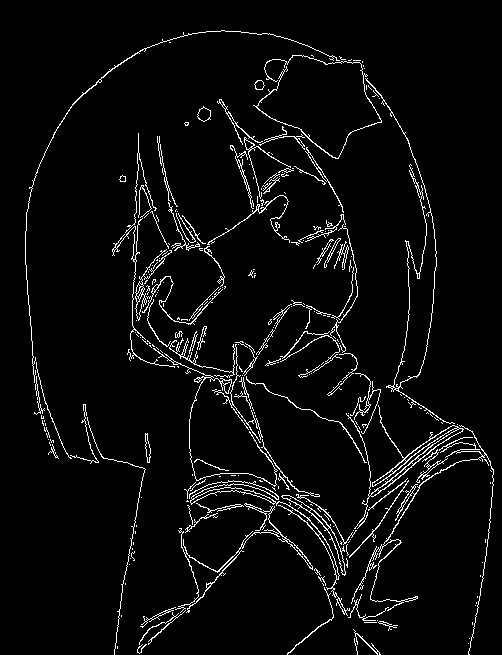

In [6]:
Image.fromarray(edged)

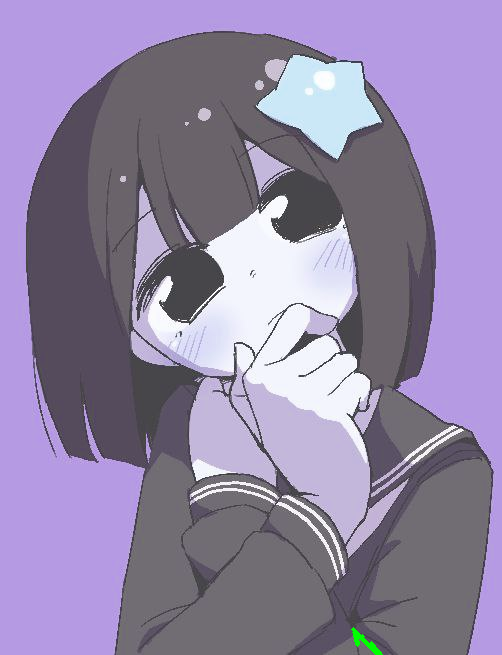

In [7]:
Image.fromarray(image)